# Building the kilonova transformer — a tutorial

`hourglass_eda.ipynb` ends at a PyTorch `DataLoader` that turns each transient's early light
curve into a small **set of tokens**: one per (band × visit), each carrying its time, band,
magnitude, and a type flag (detection `d` / 5σ upper limit `u` / instrumental gap `n`), plus
one global redshift token `[Z]`. This notebook builds, from scratch and step by step, the
**encoder-only transformer** that classifies those token sets into `{Ia, II, other, KN}`.

It is modelled on the [UvA DL tutorial 6 — *Transformers and Multi-Head Attention*](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial6/Transformers_and_MHAttention.html)
(`scaled_dot_product` → `MultiheadAttention` → `EncoderBlock` → `TransformerEncoder`), with
two physics-driven changes for our problem:

- **No order-based positional encoding.** Our tokens are a *set indexed by physical time*, not
  an ordered sentence. Time enters as a continuous feature *inside* each token.
- **Time encoding tuned for decay, not periodicity.** With at most 3 epochs over ~15 days there
  is no light-curve *modulation* to resolve (these are transients, not pulsating stars). The
  discriminative physics is the **decline rate** (Δmag/Δt — a kilonova fades in days, a
  supernova in weeks) together with the **detection / non-detection pattern** (a source that
  drops below 5σ between epochs is kilonova-like). The time encoding is built so attention can
  read off *decline rates*; we deliberately keep almost no periodic content.

**Scope.** We build the architecture, run a forward pass on a batch, visualize the attention,
and finish with an *overfit-one-batch* check that proves the model is wired correctly and can
learn. Training on the real split, the on-the-fly KN injection, and the early-classification
degradation matrix are the next notebook.

In [1]:
%matplotlib inline
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# --- model size (plan.md: 2-4 layers, d_model 64-128, 4 heads) ---
D_MODEL = 64
NUM_HEADS = 4
NUM_LAYERS = 2
D_FEEDFORWARD = 128
DROPOUT = 0.1
NUM_CLASSES = 4

# --- token vocabulary ---
NUM_BANDS = 6
NUM_TOKEN_TYPES = 3
D_BAND = 16
D_TYPE = 16

# --- time encoding ---
TIME2VEC_FREQUENCIES = 6
DELTA_TIME_SCALE = 5.0  # the 5-day cadence; conditions raw Delta t before the time encoding

BAND_ORDER = ['R', 'Z', 'Y', 'J', 'H', 'F']
TOKEN_TYPE_ORDER = ['d', 'u', 'n']
GROUP_ORDER = ['Ia', 'II', 'other', 'KN']

BAND_TO_INDEX = {band: index for index, band in enumerate(BAND_ORDER)}
TOKEN_TYPE_TO_INDEX = {token_type: index for index, token_type in enumerate(TOKEN_TYPE_ORDER)}

# the per-object dict the dataloader (collate_token_windows in hourglass_eda.ipynb) emits
PER_TOKEN_KEYS = [
    'delta_time', 'band_index', 'token_type_index',
    'magnitude', 'sigma_magnitude', 'magnitude_mask', 'sigma_mask',
]
GLOBAL_KEYS = ['redshift', 'redshift_error', 'has_redshift']

BAND_COLORS = {
    band: plt.cm.turbo(position)
    for band, position in zip(BAND_ORDER, np.linspace(0.05, 0.95, len(BAND_ORDER)))
}
TOKEN_MARKERS = {'d': 'o', 'u': 'v', 'n': 's'}
TOKEN_LABELS = {'d': 'detection', 'u': '5 sigma upper limit', 'n': 'not observed'}

print(f'torch {torch.__version__}  |  numpy {np.__version__}')

torch 2.10.0  |  numpy 2.4.3


## The batch contract

The model consumes exactly what `collate_token_windows` produces — nothing more. Per batch of
`B` objects, padded to the longest token sequence `T`:

| key | shape | dtype | meaning |
|---|---|---|---|
| `delta_time` | `(B, T)` | float | days since first detection (Δt = 0 at the anchor) |
| `band_index` | `(B, T)` | long | index into `R Z Y J H F` |
| `token_type_index` | `(B, T)` | long | `0=d` detection, `1=u` 5σ upper limit, `2=n` gap |
| `magnitude`, `sigma_magnitude` | `(B, T)` | float | globally-normalized; `0` where masked |
| `magnitude_mask`, `sigma_mask` | `(B, T)` | float | `1` if that channel carries information |
| `padding_mask` | `(B, T)` | bool | `True` = padded slot the attention must ignore |
| `redshift`, `redshift_error`, `has_redshift` | `(B,)` | float | the global `[Z]` fields |
| `label` | `(B,)` | long | target class in `GROUP_ORDER` |

For this architecture notebook we synthesize a small, hand-designed batch with the same keys,
dtypes and shapes, built to contain a clear **fast fader** (kilonova-like) and a **slow
supernova** so the attention has something physical to latch onto. Swapping in the real loader
is a one-liner — `next(iter(train_loader))` from `hourglass_eda.ipynb` returns this same dict.

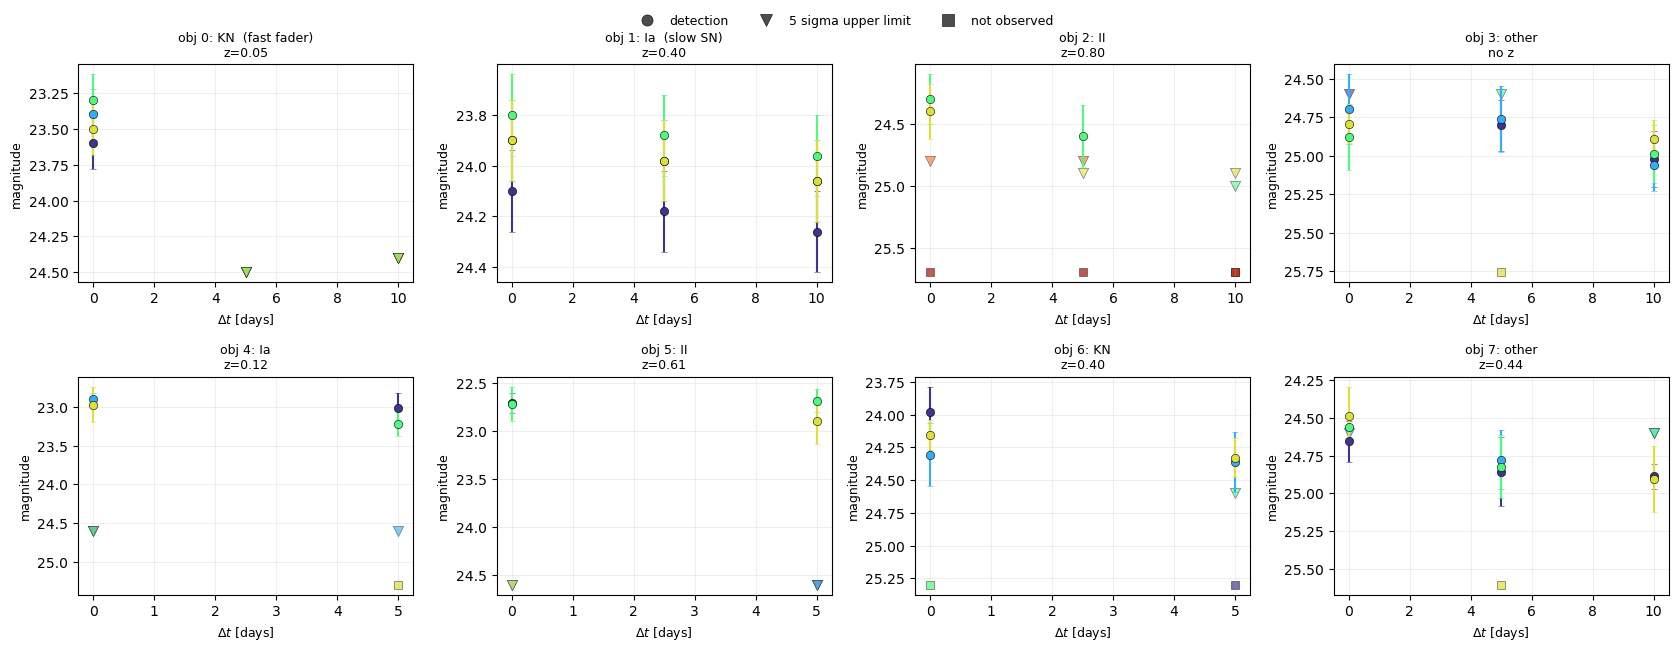

batch keys and shapes:
  delta_time         (8, 12)  torch.float32
  band_index         (8, 12)  torch.int64
  token_type_index   (8, 12)  torch.int64
  magnitude          (8, 12)  torch.float32
  sigma_magnitude    (8, 12)  torch.float32
  magnitude_mask     (8, 12)  torch.float32
  sigma_mask         (8, 12)  torch.float32
  padding_mask       (8, 12)  torch.bool
  redshift           (8,)  torch.float32
  redshift_error     (8,)  torch.float32
  has_redshift       (8,)  torch.float32
  label              (8,)  torch.int64


In [2]:
# A synthetic batch matching the dataloader contract, with a designed fast-fader vs slow-SN
# contrast. (In production replace make_synthetic_batch() with next(iter(train_loader)).)

SYNTHETIC_MAG_MEAN, SYNTHETIC_MAG_STD = 24.0, 1.5
SYNTHETIC_SIGMA_MEAN, SYNTHETIC_SIGMA_STD = 0.15, 0.08

WIDE_BANDS = ['R', 'Z', 'Y', 'J']
DEEP_BANDS = ['Y', 'J', 'H', 'F']
FADER_INDEX = 0     # object 0: kilonova-like fast fader
SLOW_SN_INDEX = 1   # object 1: slow supernova


def _fast_fader_tokens():
    # bright detections at epoch 1, then everything drops below 5 sigma -> upper limits.
    # the days-fast collapse from d to u is the kilonova-like signature.
    tokens = []
    for band, magnitude in [('R', 23.6), ('Z', 23.4), ('Y', 23.3), ('J', 23.5)]:
        tokens.append((0.0, band, 'd', magnitude, 0.18))
    for band in WIDE_BANDS:
        tokens.append((5.0, band, 'u', 24.5, np.nan))
    for band in WIDE_BANDS:
        tokens.append((10.0, band, 'u', 24.4, np.nan))
    return tokens


def _slow_supernova_tokens():
    # detected in every epoch, magnitude barely changes -> weeks-long evolution (not a KN).
    tokens = []
    for epoch_index, delta_time in enumerate([0.0, 5.0, 10.0]):
        for band, base_magnitude in [('R', 24.1), ('Z', 23.9), ('Y', 23.8), ('J', 23.9)]:
            tokens.append((delta_time, band, 'd', base_magnitude + 0.08 * epoch_index, 0.16))
    return tokens


def _deep_with_gaps_tokens():
    # a DEEP-tier object with instrumental gaps (n) and a mix of d / u.
    pattern = {
        0.0:  {'Y': ('d', 24.3, 0.20), 'J': ('d', 24.4, 0.22), 'H': ('u', 24.8, np.nan), 'F': ('n', np.nan, np.nan)},
        5.0:  {'Y': ('d', 24.6, 0.25), 'J': ('u', 24.9, np.nan), 'H': ('u', 24.8, np.nan), 'F': ('n', np.nan, np.nan)},
        10.0: {'Y': ('u', 25.0, np.nan), 'J': ('u', 24.9, np.nan), 'H': ('n', np.nan, np.nan), 'F': ('n', np.nan, np.nan)},
    }
    tokens = []
    for delta_time, band_dict in pattern.items():
        for band in DEEP_BANDS:
            token_type, magnitude, sigma = band_dict[band]
            tokens.append((delta_time, band, token_type, magnitude, sigma))
    return tokens


def _random_object_tokens(random_generator):
    number_of_epochs = int(random_generator.integers(1, 4))
    base_magnitude = float(random_generator.uniform(22.5, 25.0))
    tokens = []
    for epoch_index in range(number_of_epochs):
        delta_time = 5.0 * epoch_index
        for band in WIDE_BANDS:
            roll = random_generator.random()
            if roll < 0.6:
                magnitude = base_magnitude + 0.15 * epoch_index + float(random_generator.normal(0, 0.1))
                tokens.append((delta_time, band, 'd', magnitude, float(random_generator.uniform(0.08, 0.25))))
            elif roll < 0.85:
                tokens.append((delta_time, band, 'u', 24.6, np.nan))
            else:
                tokens.append((delta_time, band, 'n', np.nan, np.nan))
    return tokens


def _build_object_specs():
    random_generator = np.random.default_rng(7)
    specs = [
        {'tokens': _fast_fader_tokens(),     'redshift': 0.05, 'redshift_error': 0.01, 'has_redshift': 1.0, 'label': GROUP_ORDER.index('KN')},
        {'tokens': _slow_supernova_tokens(), 'redshift': 0.40, 'redshift_error': 0.05, 'has_redshift': 1.0, 'label': GROUP_ORDER.index('Ia')},
        {'tokens': _deep_with_gaps_tokens(), 'redshift': 0.80, 'redshift_error': 0.10, 'has_redshift': 1.0, 'label': GROUP_ORDER.index('II')},
        {'tokens': _random_object_tokens(random_generator), 'redshift': 0.0, 'redshift_error': 0.0, 'has_redshift': 0.0, 'label': GROUP_ORDER.index('other')},
    ]
    for label_name in ['Ia', 'II', 'KN', 'other']:
        redshift = float(random_generator.uniform(0.1, 1.5))
        specs.append({
            'tokens': _random_object_tokens(random_generator),
            'redshift': redshift,
            'redshift_error': 0.05 * redshift,
            'has_redshift': 1.0,
            'label': GROUP_ORDER.index(label_name),
        })
    return specs


def _encode_object(token_list, redshift, redshift_error, has_redshift, label):
    delta_time = np.array([token[0] for token in token_list], dtype=np.float32)
    band_index = np.array([BAND_TO_INDEX[token[1]] for token in token_list], dtype=np.int64)
    token_type_index = np.array([TOKEN_TYPE_TO_INDEX[token[2]] for token in token_list], dtype=np.int64)
    raw_magnitude = np.array([token[3] for token in token_list], dtype=np.float32)
    raw_sigma = np.array([token[4] for token in token_list], dtype=np.float32)

    magnitude_mask = ~np.isnan(raw_magnitude)
    sigma_mask = ~np.isnan(raw_sigma)
    magnitude = np.where(magnitude_mask, (raw_magnitude - SYNTHETIC_MAG_MEAN) / SYNTHETIC_MAG_STD, 0.0).astype(np.float32)
    sigma_magnitude = np.where(sigma_mask, (raw_sigma - SYNTHETIC_SIGMA_MEAN) / SYNTHETIC_SIGMA_STD, 0.0).astype(np.float32)

    return {
        'delta_time': torch.from_numpy(delta_time),
        'band_index': torch.from_numpy(band_index),
        'token_type_index': torch.from_numpy(token_type_index),
        'magnitude': torch.from_numpy(magnitude),
        'sigma_magnitude': torch.from_numpy(sigma_magnitude),
        'magnitude_mask': torch.from_numpy(magnitude_mask.astype(np.float32)),
        'sigma_mask': torch.from_numpy(sigma_mask.astype(np.float32)),
        'redshift': torch.tensor(redshift, dtype=torch.float32),
        'redshift_error': torch.tensor(redshift_error, dtype=torch.float32),
        'has_redshift': torch.tensor(float(has_redshift), dtype=torch.float32),
        'label': torch.tensor(label, dtype=torch.long),
    }


def _collate(items):
    batch_size = len(items)
    max_tokens = max(item['delta_time'].shape[0] for item in items)
    padded = {
        key: torch.zeros(batch_size, max_tokens, dtype=items[0][key].dtype)
        for key in PER_TOKEN_KEYS
    }
    padding_mask = torch.ones(batch_size, max_tokens, dtype=torch.bool)
    for row_index, item in enumerate(items):
        number_of_tokens = item['delta_time'].shape[0]
        for key in PER_TOKEN_KEYS:
            padded[key][row_index, :number_of_tokens] = item[key]
        padding_mask[row_index, :number_of_tokens] = False

    collated = dict(padded)
    collated['padding_mask'] = padding_mask
    for key in GLOBAL_KEYS:
        collated[key] = torch.stack([item[key] for item in items])
    collated['label'] = torch.stack([item['label'] for item in items])
    return collated


def plot_synthetic_light_curves(object_specs):
    number_of_objects = len(object_specs)
    number_of_columns = 4
    number_of_rows = int(np.ceil(number_of_objects / number_of_columns))
    figure, axes = plt.subplots(number_of_rows, number_of_columns,
                                figsize=(4.2 * number_of_columns, 3.2 * number_of_rows),
                                squeeze=False)
    for object_index, spec in enumerate(object_specs):
        axis = axes[object_index // number_of_columns][object_index % number_of_columns]
        measured = [token for token in spec['tokens'] if not np.isnan(token[3])]
        faintest = max(token[3] for token in measured) if measured else 25.0
        strip_magnitude = faintest + 0.7
        for delta_time, band, token_type, magnitude, sigma in spec['tokens']:
            color = BAND_COLORS[band]
            if token_type == 'd':
                axis.errorbar(delta_time, magnitude, yerr=sigma, fmt='o', color=color,
                              markersize=6, markeredgecolor='black', markeredgewidth=0.4, capsize=2)
            elif token_type == 'u':
                axis.scatter(delta_time, magnitude, marker='v', color=color, s=55,
                             edgecolor='black', linewidth=0.4, alpha=0.6)
            else:
                axis.scatter(delta_time, strip_magnitude, marker='s', facecolor=color,
                             edgecolor='black', linewidth=0.4, s=30, alpha=0.7)
        axis.invert_yaxis()
        axis.set_xlabel(r'$\Delta t$ [days]', fontsize=9)
        axis.set_ylabel('magnitude', fontsize=9)
        tag = ''
        if object_index == FADER_INDEX:
            tag = '  (fast fader)'
        elif object_index == SLOW_SN_INDEX:
            tag = '  (slow SN)'
        redshift_tag = f"z={spec['redshift']:.2f}" if spec['has_redshift'] else 'no z'
        axis.set_title(f"obj {object_index}: {GROUP_ORDER[spec['label']]}{tag}\n{redshift_tag}", fontsize=9)
        axis.grid(alpha=0.2)
    for empty_index in range(number_of_objects, number_of_rows * number_of_columns):
        axes[empty_index // number_of_columns][empty_index % number_of_columns].set_visible(False)

    marker_handles = [
        plt.Line2D([0], [0], marker=TOKEN_MARKERS[token_type], color='0.3', linestyle='none',
                   markersize=8, markeredgecolor='black', markeredgewidth=0.4, label=TOKEN_LABELS[token_type])
        for token_type in TOKEN_TYPE_ORDER
    ]
    figure.legend(handles=marker_handles, loc='upper center', ncol=3, frameon=False,
                  bbox_to_anchor=(0.5, 1.02), fontsize=9)
    plt.tight_layout()
    plt.show()


def make_synthetic_batch(plot=True):
    object_specs = _build_object_specs()
    items = [
        _encode_object(spec['tokens'], spec['redshift'], spec['redshift_error'],
                       spec['has_redshift'], spec['label'])
        for spec in object_specs
    ]
    batch = _collate(items)
    if plot:
        plot_synthetic_light_curves(object_specs)
    return batch


synthetic_batch = make_synthetic_batch(plot=True)
print('batch keys and shapes:')
for key, tensor in synthetic_batch.items():
    print(f'  {key:18s} {tuple(tensor.shape)}  {tensor.dtype}')

## 1 — Scaled dot-product attention

Attention is a content-based lookup. Each token emits a **query**, every token a **key** and a
**value**; the query is compared (dot product) against all keys to produce weights, and the
output is the weighted sum of values. There is no notion of order — exactly what we want, since
our tokens are a *set*.

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling keeps the logits from growing with dimension (which would saturate the
softmax). Two adaptations versus the textbook version:

- **Padding mask.** Batched objects are padded to a common length; padded *keys* must be
  unreachable. We add $-\infty$ to their logits before the softmax so their weight is zero.
- **We return the attention weights**, so we can later inspect what the `[CLS]` token reads.

This is the only place attention can turn the raw tokens into the physics we care about: by
comparing two same-band tokens at different Δt it can form a **decline rate**, and by reading a
detection next to later upper-limit tokens it sees a **fast fade**.

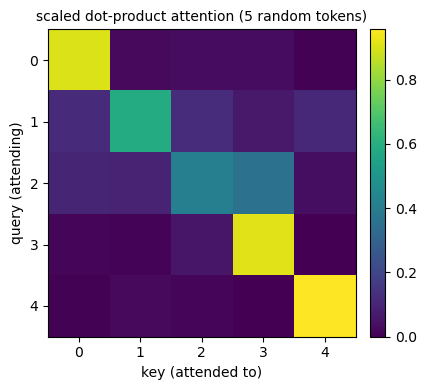

In [3]:
def scaled_dot_product(query, key, value, mask=None):
    '''Attention for tensors shaped (..., sequence_length, head_dimension).

    mask uses 1 = keep, 0 = ignore (padded key); masked logits go to -inf before the softmax.
    Returns (values, attention_weights).
    '''
    head_dimension = query.size(-1)
    attention_logits = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(head_dimension)
    if mask is not None:
        attention_logits = attention_logits.masked_fill(mask == 0, -9e15)
    attention_weights = F.softmax(attention_logits, dim=-1)
    values = torch.matmul(attention_weights, value)
    return values, attention_weights


def plot_attention_matrix(attention_weights, token_labels=None, title='', axis=None):
    created_axis = axis is None
    if created_axis:
        figure, axis = plt.subplots(figsize=(4.5, 4.0))
    image = axis.imshow(attention_weights, cmap='viridis', vmin=0.0)
    if token_labels is not None:
        axis.set_xticks(range(len(token_labels)))
        axis.set_xticklabels(token_labels, rotation=90, fontsize=8)
        axis.set_yticks(range(len(token_labels)))
        axis.set_yticklabels(token_labels, fontsize=8)
    axis.set_xlabel('key (attended to)')
    axis.set_ylabel('query (attending)')
    axis.set_title(title, fontsize=10)
    if created_axis:
        plt.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
    return image


def demo_scaled_dot_product(plot=True):
    torch.manual_seed(1)
    sequence_length, dimension = 5, 8
    query = torch.randn(1, sequence_length, dimension)
    _, attention_weights = scaled_dot_product(query, query, query)
    if plot:
        plot_attention_matrix(attention_weights[0].detach().numpy(),
                              title='scaled dot-product attention (5 random tokens)')
    return attention_weights


_ = demo_scaled_dot_product(plot=True)

## 2 — Multi-head attention

One attention pattern is limiting: the model may need to compare *the same band across time*
(to get a decline rate) **and** *different bands at the same time* (to get a color) **and**
*detections against upper limits* (to spot a fade) — all at once. Multi-head attention runs `h`
attention operations in parallel on `h` learned projections of the tokens, so different heads
can specialize, then concatenates them.

We follow the UvA tutorial: a single linear layer produces all queries, keys and values
($3\,d_{\text{model}}$ wide), we reshape into `(batch, heads, sequence, head_dim)`, apply
`scaled_dot_product` per head, then a final output projection mixes the heads back together.
The padding mask is broadcast over the head and query axes — it only depends on *which key* is
padded.

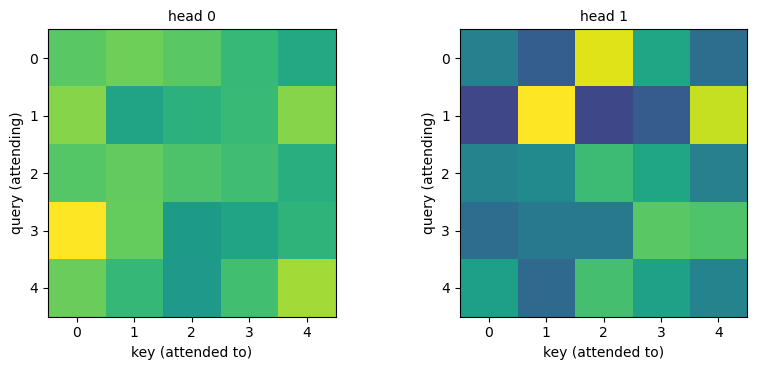

In [4]:
class MultiheadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dimension = d_model // num_heads
        self.qkv_projection = nn.Linear(d_model, 3 * d_model)
        self.output_projection = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, sequence_length, _ = x.shape
        qkv = self.qkv_projection(x)
        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dimension)
        qkv = qkv.permute(0, 2, 1, 3)
        query, key, value = qkv.chunk(3, dim=-1)
        values, attention_weights = scaled_dot_product(query, key, value, mask=mask)
        values = values.permute(0, 2, 1, 3).reshape(batch_size, sequence_length, self.d_model)
        output = self.output_projection(values)
        if return_attention:
            return output, attention_weights
        return output


def demo_multihead_attention(plot=True):
    torch.manual_seed(2)
    demo_heads, demo_dimension, sequence_length = 2, 8, 5
    attention_module = MultiheadAttention(demo_dimension, demo_heads)
    x = torch.randn(1, sequence_length, demo_dimension)
    _, attention_weights = attention_module(x, return_attention=True)
    if plot:
        figure, axes = plt.subplots(1, demo_heads, figsize=(4.2 * demo_heads, 3.8))
        for head_index in range(demo_heads):
            plot_attention_matrix(attention_weights[0, head_index].detach().numpy(),
                                  title=f'head {head_index}', axis=axes[head_index])
        plt.tight_layout()
        plt.show()
    return attention_weights


_ = demo_multihead_attention(plot=True)

## 3 — Encoding time: decline, not modulation

A standard transformer adds a **positional encoding** — a bank of sines and cosines of the
token *index* — to inject order. We do **not** want that: our tokens have no order, and their
index is meaningless. What is meaningful is the *physical time* Δt of each visit.

We encode Δt with **time2vec** (Kazemi et al. 2019):

$$\text{time2vec}(\Delta t) = \big[\;\underbrace{\omega_0\,\Delta t + \varphi_0}_{\text{linear}},\;
\underbrace{\sin(\omega_1 \Delta t + \varphi_1),\,\dots,\,\sin(\omega_k \Delta t + \varphi_k)}_{\text{periodic}}\;\big]$$

The split matters for our physics:

- The **linear term** is the workhorse. It makes Δt available as a quantity attention can
  *difference*: comparing two tokens gives Δmag and Δt, hence the **decline rate** — the single
  most discriminative feature (kilonova: ~1 mag/day; supernova: ~0.05 mag/day).
- The **periodic terms** would capture a *modulation* (a pulsation, an orbit). Over 3 epochs in
  ~15 days there is nothing periodic to fit and no physical periodicity to expect, so we keep
  only a **few low-frequency** components (periods comparable to the window) and initialize the
  linear weight to dominate. **No high-frequency Fourier modulation.**

Contrast this with the UvA tutorial's `PositionalEncoding`, which is *fixed* high-to-low
frequency sinusoids of the integer position — the opposite of what a 3-epoch transient needs.

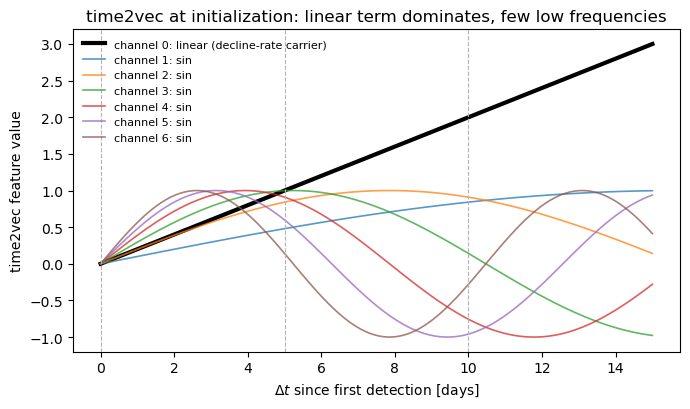

In [5]:
class Time2Vec(nn.Module):
    '''Continuous time encoding. Channel 0 is linear in Delta t (the decline-rate carrier); the
    remaining channels are a few low-frequency sinusoids. A final linear layer lifts the
    (num_frequencies + 1) features to output_dimension.'''

    def __init__(self, num_frequencies, output_dimension, delta_time_scale=DELTA_TIME_SCALE):
        super().__init__()
        self.delta_time_scale = delta_time_scale
        self.linear_weight = nn.Parameter(torch.ones(1))
        self.linear_bias = nn.Parameter(torch.zeros(1))
        # low frequencies: in scaled-time units, periods ~ 2 to 12 (i.e. ~10-60 d unscaled)
        self.frequency_weight = nn.Parameter(torch.linspace(0.5, 3.0, num_frequencies))
        self.frequency_bias = nn.Parameter(torch.zeros(num_frequencies))
        self.projection = nn.Linear(num_frequencies + 1, output_dimension)

    def time_features(self, delta_time):
        scaled_time = (delta_time / self.delta_time_scale).unsqueeze(-1)
        linear_term = self.linear_weight * scaled_time + self.linear_bias
        periodic_terms = torch.sin(scaled_time * self.frequency_weight + self.frequency_bias)
        return torch.cat([linear_term, periodic_terms], dim=-1)

    def forward(self, delta_time):
        return self.projection(self.time_features(delta_time))


def plot_time2vec(time2vec_module, plot=True):
    delta_time = torch.linspace(0.0, 15.0, 120)
    with torch.no_grad():
        features = time2vec_module.time_features(delta_time).numpy()
    if plot:
        figure, axis = plt.subplots(figsize=(7.0, 4.2))
        axis.plot(delta_time.numpy(), features[:, 0], color='black', lw=3,
                  label='channel 0: linear (decline-rate carrier)')
        for channel_index in range(1, features.shape[1]):
            axis.plot(delta_time.numpy(), features[:, channel_index], lw=1.2, alpha=0.75,
                      label=f'channel {channel_index}: sin')
        for epoch_delta_time in [0.0, 5.0, 10.0]:
            axis.axvline(epoch_delta_time, color='0.7', ls='--', lw=0.8)
        axis.set_xlabel(r'$\Delta t$ since first detection [days]')
        axis.set_ylabel('time2vec feature value')
        axis.set_title('time2vec at initialization: linear term dominates, few low frequencies')
        axis.legend(fontsize=8, loc='upper left', frameon=False)
        plt.tight_layout()
        plt.show()
    return features


_ = plot_time2vec(Time2Vec(TIME2VEC_FREQUENCIES, D_MODEL), plot=True)

## 4 — From token fields to a d_model vector

Each token's fields are embedded and **fused** into one `d_model` vector:

- `band_index` → a learned **band embedding** (color identity).
- `token_type_index` → a learned **type embedding** over `{d, u, n}`. This is the channel that
  carries the **detection / non-detection structure** — co-equal with the decline rate as the
  kilonova discriminator. An object that goes `d → u → u` is fading fast.
- `(magnitude, σ_mag, magnitude_mask, sigma_mask)` → a small linear projection. The masks are
  passed in so the model can tell a *real* normalized 0 from an *absent* channel (`u` has no
  error, `n` has no magnitude).

These are concatenated and projected to `d_model`, LayerNorm-ed, and the **time2vec(Δt) code is
added** — exactly where a vanilla transformer would add its positional encoding.

Two **global tokens** are prepended, one per object (no time, no band):

- **`[CLS]`** — a learned vector whose final state we read out for classification.
- **`[Z]`** — the redshift. `(z, σ_z)` is projected to `d_model` when present; when absent
  (`has_redshift = 0`) a learned **`[NO_Z]`** vector is used instead. z carries the physics
  *z × photometry → luminosity* (a mag-24 transient at z = 1 is too luminous to be a KN).

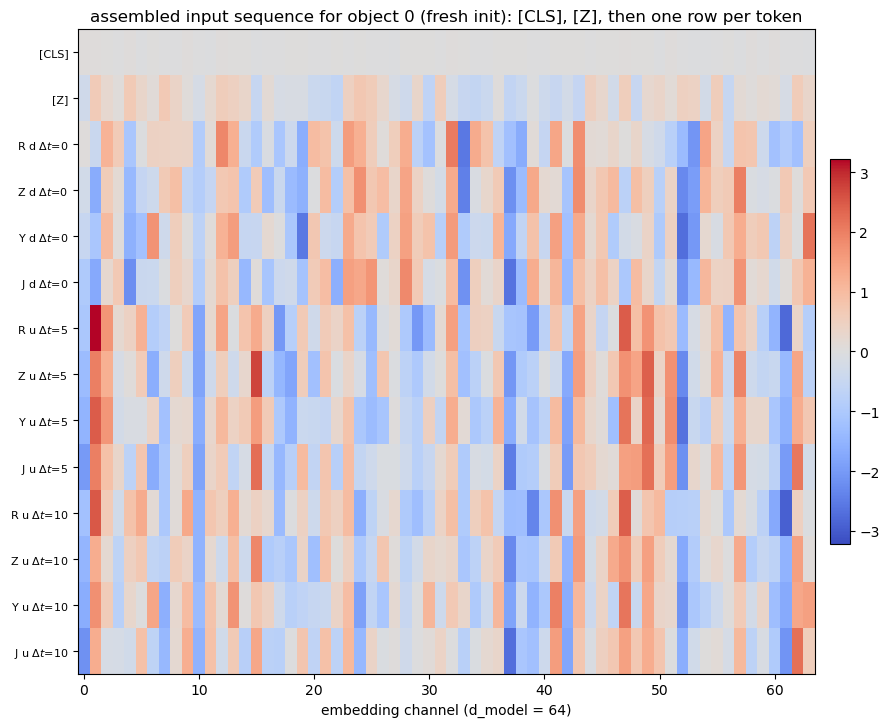

In [6]:
class TokenEmbedding(nn.Module):
    def __init__(self, d_model=D_MODEL):
        super().__init__()
        self.band_embedding = nn.Embedding(NUM_BANDS, D_BAND)
        self.token_type_embedding = nn.Embedding(NUM_TOKEN_TYPES, D_TYPE)
        self.magnitude_projection = nn.Linear(4, d_model)
        self.content_projection = nn.Linear(D_BAND + D_TYPE + d_model, d_model)
        self.content_norm = nn.LayerNorm(d_model)
        self.time_encoding = Time2Vec(TIME2VEC_FREQUENCIES, d_model)

    def forward(self, batch):
        band = self.band_embedding(batch['band_index'])
        token_type = self.token_type_embedding(batch['token_type_index'])
        magnitude_features = torch.stack(
            [batch['magnitude'], batch['sigma_magnitude'], batch['magnitude_mask'], batch['sigma_mask']],
            dim=-1,
        )
        magnitude = self.magnitude_projection(magnitude_features)
        content = torch.cat([band, token_type, magnitude], dim=-1)
        content = self.content_norm(self.content_projection(content))
        return content + self.time_encoding(batch['delta_time'])


class GlobalTokens(nn.Module):
    def __init__(self, d_model=D_MODEL):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.no_redshift_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.redshift_projection = nn.Linear(2, d_model)

    def forward(self, batch):
        batch_size = batch['redshift'].shape[0]
        cls_token = self.cls_token.expand(batch_size, -1, -1)
        redshift_features = torch.stack([batch['redshift'], batch['redshift_error']], dim=-1)
        redshift_token = self.redshift_projection(redshift_features).unsqueeze(1)
        has_redshift = batch['has_redshift'].view(batch_size, 1, 1)
        redshift_token = (has_redshift * redshift_token
                          + (1.0 - has_redshift) * self.no_redshift_token.expand(batch_size, -1, -1))
        return cls_token, redshift_token


def plot_assembled_sequence(batch, object_index=FADER_INDEX, plot=True):
    token_embedding = TokenEmbedding()
    global_tokens = GlobalTokens()
    with torch.no_grad():
        token_vectors = token_embedding(batch)
        cls_token, redshift_token = global_tokens(batch)
    keep = ~batch['padding_mask'][object_index]
    sequence = torch.cat(
        [cls_token[object_index], redshift_token[object_index], token_vectors[object_index][keep]],
        dim=0,
    ).detach().numpy()

    row_labels = ['[CLS]', '[Z]']
    for band_index, token_type_index, delta_time in zip(
        batch['band_index'][object_index][keep].numpy(),
        batch['token_type_index'][object_index][keep].numpy(),
        batch['delta_time'][object_index][keep].numpy(),
    ):
        row_labels.append(f'{BAND_ORDER[band_index]} {TOKEN_TYPE_ORDER[token_type_index]} '
                          rf'$\Delta t$={delta_time:.0f}')

    if plot:
        figure, axis = plt.subplots(figsize=(9.0, 0.42 * len(row_labels) + 1.5))
        limit = np.abs(sequence).max()
        image = axis.imshow(sequence, cmap='coolwarm', aspect='auto', vmin=-limit, vmax=limit)
        axis.set_yticks(range(len(row_labels)))
        axis.set_yticklabels(row_labels, fontsize=8)
        axis.set_xlabel(f'embedding channel (d_model = {sequence.shape[1]})')
        axis.set_title(f'assembled input sequence for object {object_index} (fresh init): '
                       f'[CLS], [Z], then one row per token')
        plt.colorbar(image, ax=axis, fraction=0.025, pad=0.02)
        plt.tight_layout()
        plt.show()
    return sequence


_ = plot_assembled_sequence(synthetic_batch, object_index=FADER_INDEX, plot=True)

## 5 — The encoder block (pre-LayerNorm)

An encoder block is multi-head self-attention followed by a small position-wise MLP, each
wrapped in a residual connection. We use the **pre-LayerNorm** arrangement

$$x \leftarrow x + \text{MHA}(\text{LN}(x)), \qquad x \leftarrow x + \text{FFN}(\text{LN}(x))$$

rather than the UvA tutorial's post-LayerNorm. Pre-LN keeps a clean residual path and trains
more stably without a learning-rate warmup — worth it here, where we have only ~10k real
contaminants and a small model. The MLP is `Linear → GELU → Dropout → Linear` with an inner
width of `D_FEEDFORWARD`.

input (1, 6, 64) -> output (1, 6, 64) (shape preserved)
2 layers, each attention map (1, 4, 6, 6) (batch, heads, q, k)


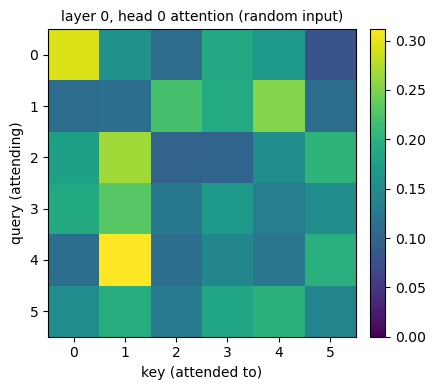

In [7]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, num_heads=NUM_HEADS, d_feedforward=D_FEEDFORWARD, dropout=DROPOUT):
        super().__init__()
        self.attention = MultiheadAttention(d_model, num_heads)
        self.attention_norm = nn.LayerNorm(d_model)
        self.feedforward_norm = nn.LayerNorm(d_model)
        self.feedforward = nn.Sequential(
            nn.Linear(d_model, d_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_feedforward, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attention_output = self.attention(self.attention_norm(x), mask=mask)
        x = x + self.dropout(attention_output)
        feedforward_output = self.feedforward(self.feedforward_norm(x))
        x = x + feedforward_output
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, num_layers=NUM_LAYERS, **block_kwargs):
        super().__init__()
        self.layers = nn.ModuleList([EncoderBlock(**block_kwargs) for _ in range(num_layers)])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask=mask)
        return x

    def get_attention_maps(self, x, mask=None):
        attention_maps = []
        for layer in self.layers:
            _, attention_weights = layer.attention(layer.attention_norm(x), mask=mask, return_attention=True)
            attention_maps.append(attention_weights)
            x = layer(x, mask=mask)
        return attention_maps


def demo_encoder(plot=True):
    torch.manual_seed(3)
    sequence_length = 6
    encoder = TransformerEncoder(num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS,
                                 d_feedforward=D_FEEDFORWARD, dropout=0.0)
    encoder.eval()
    x = torch.randn(1, sequence_length, D_MODEL)
    output = encoder(x)
    attention_maps = encoder.get_attention_maps(x)
    print(f'input {tuple(x.shape)} -> output {tuple(output.shape)} (shape preserved)')
    print(f'{len(attention_maps)} layers, each attention map {tuple(attention_maps[0].shape)} (batch, heads, q, k)')
    if plot:
        plot_attention_matrix(attention_maps[0][0, 0].detach().numpy(),
                              title='layer 0, head 0 attention (random input)')
    return output


_ = demo_encoder(plot=True)

## 6 — The full classifier

Now we assemble everything. Per batch:

1. Embed the per-token fields and add time2vec(Δt) → `(B, T, d_model)`.
2. Prepend `[CLS]` and `[Z]` → `(B, T+2, d_model)`.
3. Build the attention mask: the two global tokens are always valid; the per-token slots come
   from `~padding_mask`. The mask is shaped `(B, 1, 1, T+2)` so it zeroes out padded **keys** for
   every head and query.
4. Run the encoder, take the **`[CLS]`** output row, LayerNorm it, and project to the 4 class
   logits.

The transformer is justified here not by sequence length (we have ≤ 14 tokens) but by the
*structure*: missing bands, three token types, and a global z token that must interact with
every photometric token.

logits shape: (8, 4)   (B, num_classes)
trainable parameters: 74,978


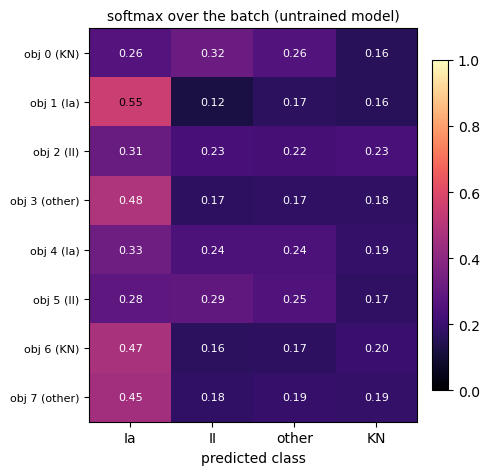

In [8]:
class KilonovaTransformer(nn.Module):
    def __init__(self, d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 d_feedforward=D_FEEDFORWARD, dropout=DROPOUT, num_classes=NUM_CLASSES):
        super().__init__()
        self.token_embedding = TokenEmbedding(d_model=d_model)
        self.global_tokens = GlobalTokens(d_model=d_model)
        self.input_dropout = nn.Dropout(dropout)
        self.encoder = TransformerEncoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                                          d_feedforward=d_feedforward, dropout=dropout)
        self.classification_norm = nn.LayerNorm(d_model)
        self.classification_head = nn.Linear(d_model, num_classes)

    def _build_sequence_and_mask(self, batch):
        token_vectors = self.token_embedding(batch)
        cls_token, redshift_token = self.global_tokens(batch)
        sequence = torch.cat([cls_token, redshift_token, token_vectors], dim=1)
        sequence = self.input_dropout(sequence)

        batch_size, total_length, _ = sequence.shape
        token_valid = ~batch['padding_mask']
        global_valid = torch.ones(batch_size, 2, dtype=torch.bool, device=token_valid.device)
        valid = torch.cat([global_valid, token_valid], dim=1)
        attention_mask = valid.view(batch_size, 1, 1, total_length)
        return sequence, attention_mask

    def forward(self, batch):
        sequence, attention_mask = self._build_sequence_and_mask(batch)
        encoded = self.encoder(sequence, mask=attention_mask)
        cls_output = encoded[:, 0]
        return self.classification_head(self.classification_norm(cls_output))

    def attention_maps(self, batch):
        sequence, attention_mask = self._build_sequence_and_mask(batch)
        return self.encoder.get_attention_maps(sequence, mask=attention_mask)


def plot_class_probabilities(model, batch, title='softmax over the batch (untrained model)', plot=True):
    model.eval()
    with torch.no_grad():
        probabilities = F.softmax(model(batch), dim=-1).numpy()
    if plot:
        figure, axis = plt.subplots(figsize=(5.0, 0.42 * probabilities.shape[0] + 1.5))
        image = axis.imshow(probabilities, cmap='magma', vmin=0.0, vmax=1.0, aspect='auto')
        axis.set_xticks(range(NUM_CLASSES))
        axis.set_xticklabels(GROUP_ORDER)
        axis.set_yticks(range(probabilities.shape[0]))
        axis.set_yticklabels([f'obj {index} ({GROUP_ORDER[int(label)]})'
                              for index, label in enumerate(batch['label'])], fontsize=8)
        for row_index in range(probabilities.shape[0]):
            for column_index in range(NUM_CLASSES):
                value = probabilities[row_index, column_index]
                axis.text(column_index, row_index, f'{value:.2f}', ha='center', va='center',
                          color='white' if value < 0.5 else 'black', fontsize=8)
        axis.set_xlabel('predicted class')
        axis.set_title(title, fontsize=10)
        plt.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
    return probabilities


model = KilonovaTransformer()
logits = model(synthetic_batch)
number_of_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'logits shape: {tuple(logits.shape)}   (B, num_classes)')
print(f'trainable parameters: {number_of_parameters:,}')
_ = plot_class_probabilities(model, synthetic_batch, plot=True)

## 7 — What does `[CLS]` look at?

Because we read the classification off the `[CLS]` token, the attention weights *from* `[CLS]`
*to* every other token are a direct, interpretable trace of the evidence the model used. We plot
that `[CLS]` row for every head and layer, with the keys labelled by `(band, type, Δt)`, for the
**fast fader** and the **slow supernova**.

On a freshly-initialized model these are near-uniform — there is nothing to see *yet*. The point
here is the read-out mechanism; after the overfit step below we look again and structure appears
(the fader's `[CLS]` concentrates on its early detections and the run of upper limits that
follow).

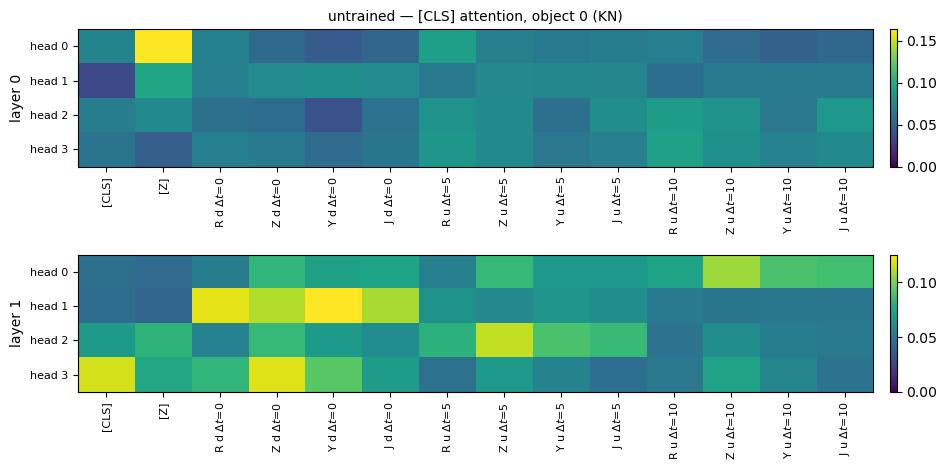

In [9]:
def plot_cls_attention(model, batch, object_index, title_prefix='', plot=True):
    model.eval()
    with torch.no_grad():
        attention_maps = model.attention_maps(batch)

    keep = ~batch['padding_mask'][object_index]
    sequence_valid = torch.cat([torch.ones(2, dtype=torch.bool), keep])
    key_labels = ['[CLS]', '[Z]']
    for band_index, token_type_index, delta_time in zip(
        batch['band_index'][object_index][keep].numpy(),
        batch['token_type_index'][object_index][keep].numpy(),
        batch['delta_time'][object_index][keep].numpy(),
    ):
        key_labels.append(f'{BAND_ORDER[band_index]} {TOKEN_TYPE_ORDER[token_type_index]} '
                          rf'$\Delta t$={delta_time:.0f}')

    cls_attention_per_layer = [
        layer_attention[object_index, :, 0, :][:, sequence_valid].numpy()
        for layer_attention in attention_maps
    ]
    number_of_layers = len(cls_attention_per_layer)

    if plot:
        figure, axes = plt.subplots(number_of_layers, 1,
                                    figsize=(0.55 * len(key_labels) + 2, 2.4 * number_of_layers),
                                    squeeze=False)
        for layer_index in range(number_of_layers):
            axis = axes[layer_index][0]
            image = axis.imshow(cls_attention_per_layer[layer_index], cmap='viridis', vmin=0.0, aspect='auto')
            axis.set_yticks(range(NUM_HEADS))
            axis.set_yticklabels([f'head {head_index}' for head_index in range(NUM_HEADS)], fontsize=8)
            axis.set_xticks(range(len(key_labels)))
            axis.set_xticklabels(key_labels, rotation=90, fontsize=8)
            axis.set_ylabel(f'layer {layer_index}')
            plt.colorbar(image, ax=axis, fraction=0.025, pad=0.02)
        axes[0][0].set_title(f'{title_prefix}[CLS] attention, object {object_index} '
                             f'({GROUP_ORDER[int(batch["label"][object_index])]})', fontsize=10)
        plt.tight_layout()
        plt.show()
    return cls_attention_per_layer


_ = plot_cls_attention(model, synthetic_batch, FADER_INDEX, title_prefix='untrained — ', plot=True)

## 8 — Sanity check: overfit one batch

Before any real training, the standard check that an architecture is wired correctly is to
**overfit a single batch**: with enough steps the loss should collapse to ~0 and the training
accuracy hit 100%. If it cannot memorize 8 examples, something is broken (a detached gradient, a
mask that hides everything, a shape bug) — no amount of data would fix it.

This is *not* a result. It says nothing about generalization; it only proves gradients flow end
to end and the model has the capacity to fit.

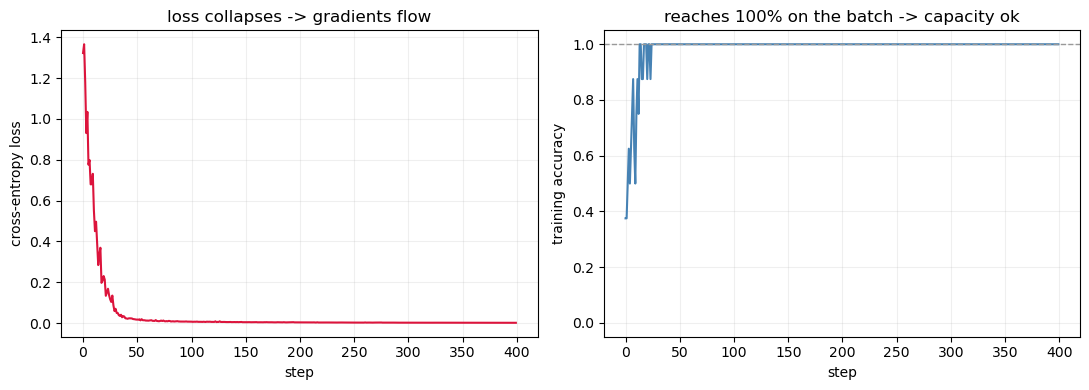

final loss 0.0012   final accuracy 1.00


In [10]:
def overfit_one_batch(model, batch, number_of_steps=400, learning_rate=1e-3, plot=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    labels = batch['label']
    loss_history = []
    accuracy_history = []
    model.train()
    for step in range(number_of_steps):
        optimizer.zero_grad()
        logits = model(batch)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        loss_history.append(float(loss.detach()))
        accuracy_history.append(float((logits.argmax(dim=-1) == labels).float().mean()))
    if plot:
        figure, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(loss_history, color='crimson')
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('cross-entropy loss')
        axes[0].set_title('loss collapses -> gradients flow')
        axes[0].grid(alpha=0.2)
        axes[1].plot(accuracy_history, color='steelblue')
        axes[1].axhline(1.0, color='0.6', ls='--', lw=1)
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('training accuracy')
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].set_title('reaches 100% on the batch -> capacity ok')
        axes[1].grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
    return loss_history, accuracy_history


overfit_model = KilonovaTransformer()
loss_history, accuracy_history = overfit_one_batch(overfit_model, synthetic_batch, plot=True)
print(f'final loss {loss_history[-1]:.4f}   final accuracy {accuracy_history[-1]:.2f}')

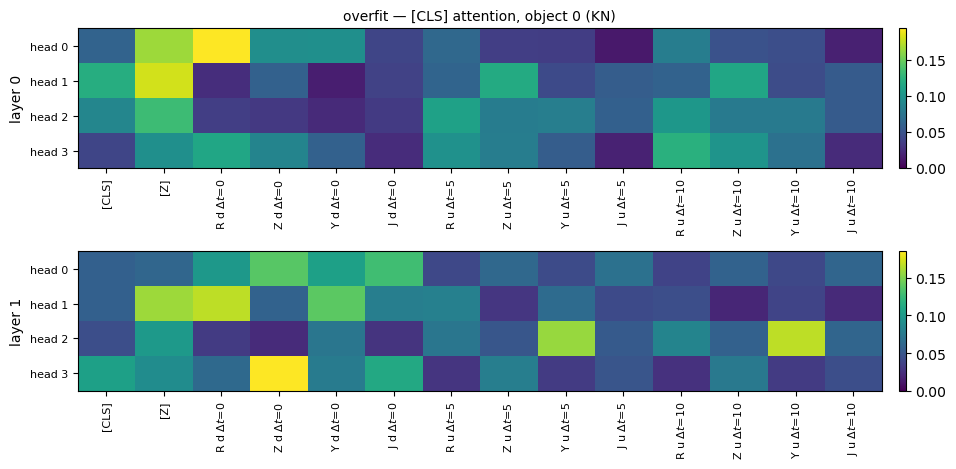

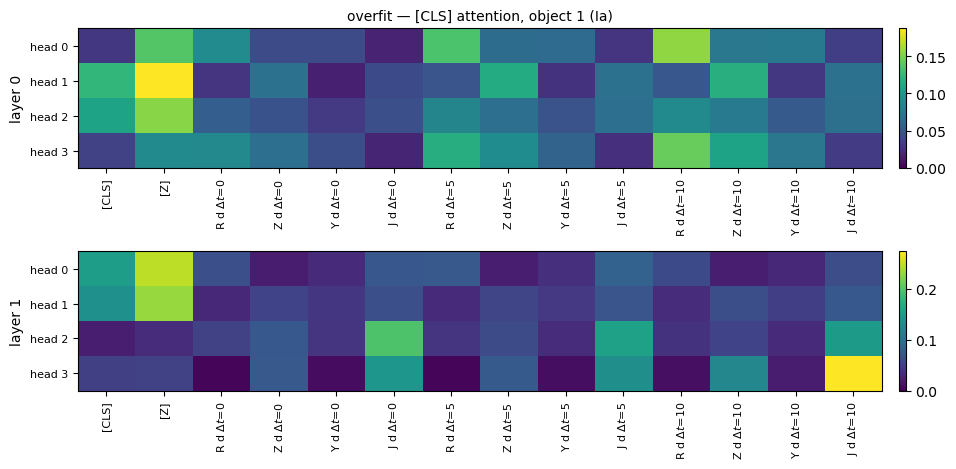

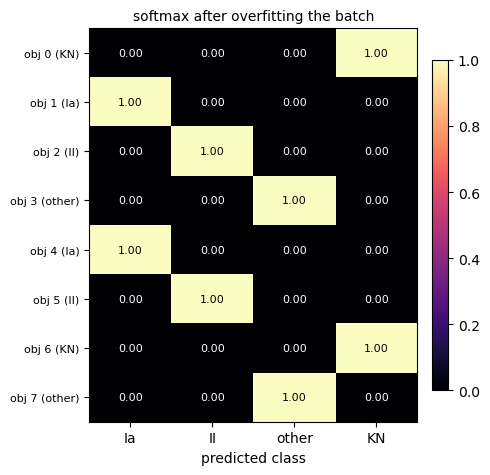

In [11]:
# now that the model has fit the batch, the [CLS] attention is structured: compare the
# fast fader against the slow supernova.
_ = plot_cls_attention(overfit_model, synthetic_batch, FADER_INDEX, title_prefix='overfit — ', plot=True)
_ = plot_cls_attention(overfit_model, synthetic_batch, SLOW_SN_INDEX, title_prefix='overfit — ', plot=True)
_ = plot_class_probabilities(overfit_model, synthetic_batch, title='softmax after overfitting the batch', plot=True)

## Recap and next steps

We built, from scratch, the encoder-only transformer the plan calls for:

- tokens as a **set** indexed by physical time — **time2vec** instead of positional encoding,
  with the **linear (decline-rate) term** doing the work and only a few low-frequency sinusoids
  (no Fourier modulation, by design, for a 3-epoch problem);
- a **type embedding** over `{d, u, n}` carrying the detection / non-detection structure;
- learned **`[CLS]`** and **`[Z]` / `[NO_Z]`** global tokens;
- pre-LayerNorm encoder blocks, `[CLS]` read-out → 4-class head;
- a forward pass, an interpretable `[CLS]`-attention view, and an overfit-one-batch proof that
  the wiring learns.

**Next notebook (training):**

1. Extract the `hourglass_eda.ipynb` dataloader into a `dataset.py` module and feed
   `train_loader` here unchanged.
2. Add the on-the-fly **KN twin generation** matched to each low-z contaminant (the matched-twin
   construction in `plan.md`).
3. Train with **random prefix truncation** (epochs 1 / 1–2 / full) and z-regime dropout.
4. Produce the **degradation matrix** — recall at a fixed candidate budget × {epoch 1, 2, 3} ×
   {spec-z, photo-z, no z} — the paper's key figure.